# About

# Packages and Libraries

In [717]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


# Data Ingestion

In [718]:
path = '../data/'

# Electricity Price in Hungary
# ref: https://ember-energy.org/data/european-wholesale-electricity-price-data/
filename = 'ember-energy.org-electricity-price-hungary-20260308.csv'
price_df = pd.read_csv(path + filename)


# Count of Electric Vehicles (EV) in Hungary
# ref: https://alternative-fuels-observatory.ec.europa.eu/transport-mode/road/hungary
filename = 'alternative-fuels-observatory.ec.europa.eu-number-of-ev-hungary-20260308.csv'
ev_count_df = pd.read_csv(path + filename)


# Top selling EVs in Hungary
# ref: https://alternative-fuels-observatory.ec.europa.eu/transport-mode/road/hungary
filename = 'alternative-fuels-observatory.ec.europa.eu-best-selling-ev-hungary-20260308.csv'
ev_type_df = pd.read_csv(path + filename)


# Useable battery capacity of EVs
# ref: https://ev-database.org/cheatsheet/useable-battery-capacity-electric-car
filename = 'ev-database.org-ev-battery-capacity-20260308.csv'
battery_capacity_df = pd.read_csv(path + filename)


# Cost of converting common station into bidirectional station
# ref: https://doi.org/10.1016/j.apenergy.2024.123679 --> Table 3
# note: this study has done in Germany
filename = 'Prospects of electric vehicle V2G multi-use_table3.csv'
station_conversion_cost_df = pd.read_csv(path + filename)

# Data Description and Cleaning

## Electricity Price in Hungary

In [719]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97679 entries, 0 to 97678
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           97679 non-null  object 
 1   ISO3 Code         97679 non-null  object 
 2   Datetime (UTC)    97679 non-null  object 
 3   Datetime (Local)  97679 non-null  object 
 4   Price (EUR/MWhe)  97679 non-null  float64
dtypes: float64(1), object(4)
memory usage: 3.7+ MB


In [720]:
price_df.tail()

,Country,ISO3 Code,Datetime (UTC),Datetime (Local),Price (EUR/MWhe)
97674,Hungary,HUN,2026-02-24 18:00:00,2026-02-24 19:00:00,146.50
97675,Hungary,HUN,2026-02-24 19:00:00,2026-02-24 20:00:00,124.68
97676,Hungary,HUN,2026-02-24 20:00:00,2026-02-24 21:00:00,117.93
97677,Hungary,HUN,2026-02-24 21:00:00,2026-02-24 22:00:00,110.75
97678,Hungary,HUN,2026-02-24 22:00:00,2026-02-24 23:00:00,99.10


This dataset is already clean, but it would be better to

- drop unnessecary columns: Country, ISO3 Code, Datetime (UTC)
- change type "Datetime (Local)" into date-time
- change price unit into EUR/KWh

In [721]:
# Keep only the columns we need
price_df = price_df.drop(columns=['Country', 'ISO3 Code', 'Datetime (UTC)'])

# Convert local datetime column to pandas datetime
price_df['Datetime'] = pd.to_datetime(price_df['Datetime (Local)'])

# Convert price from EUR/MWhe to EUR/kWh
# 1 MWh = 1000 kWh
price_df['Price'] = price_df['Price (EUR/MWhe)'] / 1000

# Drop old columns
price_df = price_df.drop(columns=['Datetime (Local)'])
price_df = price_df.drop(columns=['Price (EUR/MWhe)'])

price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97679 entries, 0 to 97678
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Datetime  97679 non-null  datetime64[ns]
 1   Price     97679 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.5 MB


In [722]:
price_df.tail()

,Datetime,Price
97674,2026-02-24 19:00:00,0.14650
97675,2026-02-24 20:00:00,0.12468
97676,2026-02-24 21:00:00,0.11793
97677,2026-02-24 22:00:00,0.11075
97678,2026-02-24 23:00:00,0.09910


## Count of EV in Hungary

In [723]:
ev_count_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  18 non-null     int64  
 1   BEV       15 non-null     float64
 2   PHEV      14 non-null     float64
 3   H2        5 non-null      float64
 4   LPG       18 non-null     int64  
 5   CNG       13 non-null     float64
 6   LNG       0 non-null      float64
dtypes: float64(5), int64(2)
memory usage: 1.1 KB


In [724]:
ev_count_df.tail()

,Category,BEV,PHEV,H2,LPG,CNG,LNG
13,2021,20278.0,8023.0,2.0,24141,2907.0,NaN
14,2022,31845.0,9970.0,5.0,23205,2909.0,NaN
15,2023,44153.0,11705.0,5.0,22507,3293.0,NaN
16,2024,70160.0,12642.0,8.0,26631,3233.0,NaN
17,2025,101167.0,13067.0,11.0,27762,3173.0,NaN


This dataset is already clean, but it would be better to

- drop unnessecary columns: H2, LPG, CNG, LNG
- change type "BEV" and "PHEV" into integer
- add "EV" column as a sum of BEV and PHEV

### Units

- All numbers are quantity of operating vehicles

In [725]:
# Keep only the columns we need
ev_count_df = ev_count_df.drop(columns=['H2', 'LPG', 'CNG', 'LNG'])

# Convert BEV and PHEV to int
ev_count_df['BEV'] = ev_count_df['BEV'].fillna(0).astype(int)
ev_count_df['PHEV'] = ev_count_df['PHEV'].fillna(0).astype(int)

# Add column EV = BEV + PHEV
ev_count_df['EV'] = ev_count_df['BEV'] + ev_count_df['PHEV']

# Rename Category into Year
ev_count_df = ev_count_df.rename(columns={'Category': 'Year'})

ev_count_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    18 non-null     int64
 1   BEV     18 non-null     int64
 2   PHEV    18 non-null     int64
 3   EV      18 non-null     int64
dtypes: int64(4)
memory usage: 708.0 bytes


In [726]:
ev_count_df.tail()

,Year,BEV,PHEV,EV
13,2021,20278,8023,28301
14,2022,31845,9970,41815
15,2023,44153,11705,55858
16,2024,70160,12642,82802
17,2025,101167,13067,114234


## Top Selling EVs in Hungary

In [727]:
ev_type_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  10 non-null     object
 1   2025      10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [728]:
ev_type_df.head()

,Category,2025
0,BMW IX1 BEV,466
1,BYD SEAL BEV,264
2,BYD SEALION 07 BEV,251
3,BYD YUAN PLUS / ATTO-3 BEV,315
4,FORD EXPLORER BEV,236


This dataset is already clean, but it would be better to

- change colume names
- remove 'BEV' from EV names
- replace 'BYD SEALION 07' with 'BYD SEALION7' (later we need it to match with battery capacity dataset)

### Units

- numbers are in KWh

In [729]:
# Rename columns
ev_type_df = ev_type_df.rename(columns={
    'Category': 'EV Model',
    '2025': 'Unit Sold 2025'
})

# Remove 'BEV' from model names
ev_type_df['EV Model'] = ev_type_df['EV Model'].str.replace(' BEV', '', regex=False)

# replace 'BYD SEALION 07' with 'BYD SEALION7' 
ev_type_df['EV Model'] = ev_type_df['EV Model'].replace({
    'BYD SEALION 07': 'BYD SEALION7'
})

ev_type_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   EV Model        10 non-null     object
 1   Unit Sold 2025  10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [730]:
ev_type_df.head(10)

,EV Model,Unit Sold 2025
0,BMW IX1,466
1,BYD SEAL,264
2,BYD SEALION7,251
3,BYD YUAN PLUS / ATTO-3,315
4,FORD EXPLORER,236
5,HYUNDAI IONIQ 5,264
6,KIA EV3,665
7,TESLA MODEL 3,536
8,TESLA MODEL Y,1022
9,VOLVO EX30,230


## Useable Battery Capacity of EVs

In [731]:
battery_capacity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EV Model  592 non-null    object 
 1   Capacity  592 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.4+ KB


In [732]:
battery_capacity_df.head()

,EV Model,Capacity
0,Lucid Gravity Grand Touring,123.0
1,Mercedes-Benz EQS SUV Maybach 680,118.0
2,Mercedes-Benz EQS SUV 450+,118.0
3,Mercedes-Benz EQS SUV 450 4MATIC,118.0
4,Mercedes-Benz EQS SUV 500 4MATIC,118.0


This dataset is already clean. Let's check if we can find capacity for top 10 EV Models...

In [733]:
# Create normalized copies for matching
def normalize_model_name(text):
    text = str(text).lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

# Normalized copies
ev_type_tmp = ev_type_df.copy()
battery_tmp = battery_capacity_df.copy()

ev_type_tmp['model_key'] = ev_type_tmp['EV Model'].apply(normalize_model_name)
battery_tmp['model_key'] = battery_tmp['EV Model'].apply(normalize_model_name)

# Manual standardization
ev_type_tmp['model_key'] = ev_type_tmp['model_key'].replace({
    'byd sealion7': 'byd sealion 7'
})

battery_tmp['model_key'] = battery_tmp['model_key'].replace({
    'byd sealion7': 'byd sealion 7'
})

def find_matches(ev_key, battery_series):
    # Match as a phrase, not as a raw substring
    pattern = rf'(^|[^a-z0-9]){re.escape(ev_key)}([^a-z0-9]|$)'
    return battery_series.str.contains(pattern, regex=True, na=False)
    
# find all battery dataset rows where the battery model contains the top model
matches = []
for _, ev_row in ev_type_tmp.iterrows():
    ev_model = ev_row['EV Model']
    units_sold = ev_row['Unit Sold 2025']
    ev_key = ev_row['model_key']
    
    mask = find_matches(ev_key, battery_tmp['model_key'])
    matched_rows = battery_tmp[mask].copy()
    
    if matched_rows.empty:
        matches.append({
            'EV Model': ev_model,
            'Unit Sold 2025': units_sold,
            'Matched Battery Model': None,
            'Capacity': None
        })
    else:
        for _, bat_row in matched_rows.iterrows():
            matches.append({
                'EV Model': ev_model,
                'Unit Sold 2025': units_sold,
                'Matched Battery Model': bat_row['EV Model'],
                'Capacity': bat_row['Capacity']
            })

ev_type_matches_df = pd.DataFrame(matches)
ev_type_matches_df

/var/folders/by/36tq7tss015bjj5q8rqwbwjw0000gn/T/ipykernel_38917/2092916616.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return battery_series.str.contains(pattern, regex=True, na=False)


,EV Model,Unit Sold 2025,Matched Battery Model,Capacity
0,BMW IX1,466,BMW iX1 eDrive20,65.2
1,BMW IX1,466,BMW iX1 xDrive30,65.2
2,BYD SEAL,264,BYD SEAL U 87 kWh Design,87.0
3,BYD SEAL,264,BYD SEAL 82.5 kWh RWD Design,82.5
4,BYD SEAL,264,BYD SEAL 82.5 kWh AWD Excellence,82.5
5,BYD SEAL,264,BYD SEAL U 71.8 kWh Comfort,71.8
6,BYD SEAL,264,BYD SEAL 61.4 kWh RWD Comfort,61.4
7,BYD SEALION7,251,BYD SEALION 7 91.3 kWh AWD Excellence,91.3
8,BYD SEALION7,251,BYD SEALION 7 82.5 kWh RWD Comfort,82.5
9,BYD SEALION7,251,BYD SEALION 7 82.5 kWh AWD Design,82.5


In [734]:
# summarize to one capacity per top-selling model

ev_profiles_df = (
    ev_type_matches_df
    .groupby(['EV Model', 'Unit Sold 2025'], as_index=False)
    .agg(
        Matched_Models=('Matched Battery Model', lambda x: ', '.join(x.dropna().astype(str))),
        Battery_Capacity=('Capacity', 'mean')
    )
)

# manualy add battery_capacity for 'BYD YUAN PLUS / ATTO-3' = average (49.92 kWh and 60.48 kWh)
ev_profiles_df.loc[
    ev_profiles_df['EV Model'] == 'BYD YUAN PLUS / ATTO-3',
    'Battery_Capacity'
] = (49.92 + 60.48) / 2

ev_profiles_df

,EV Model,Unit Sold 2025,Matched_Models,Battery_Capacity
0,BMW IX1,466,"BMW iX1 eDrive20, BMW iX1 xDrive30",65.200000
1,BYD SEAL,264,"BYD SEAL U 87 kWh Design, BYD SEAL 82.5 kWh RW...",77.040000
2,BYD SEALION7,251,"BYD SEALION 7 91.3 kWh AWD Excellence, BYD SEA...",85.433333
3,BYD YUAN PLUS / ATTO-3,315,,55.200000
4,FORD EXPLORER,236,"Ford Explorer Extended Range RWD, Ford Explore...",71.333333
5,HYUNDAI IONIQ 5,264,"Hyundai IONIQ 5 84 kWh RWD, Hyundai IONIQ 5 84...",75.000000
6,KIA EV3,665,"Kia EV3 Long Range, Kia EV3 Standard Range",66.500000
7,TESLA MODEL 3,536,"Tesla Model 3 Performance, Tesla Model 3 Premi...",74.250000
8,TESLA MODEL Y,1022,"Tesla Model Y Premium AWD, Tesla Model Y Premi...",74.833333
9,VOLVO EX30,230,"Volvo EX30 Cross Country, Volvo EX30 Single Mo...",60.636364


Well, now we have needed data for top 10 EV sold in Hungary (2025). Later we will use it to calculate the average battery capacity.

## Cost of Converting Stations

In [735]:
station_conversion_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   cost     4 non-null      object
 1   min2021  4 non-null      int64 
 2   mid2021  4 non-null      int64 
 3   max2021  4 non-null      int64 
 4   min2030  4 non-null      int64 
 5   mid2030  4 non-null      int64 
 6   max2030  4 non-null      int64 
dtypes: int64(6), object(1)
memory usage: 356.0+ bytes


In [736]:
station_conversion_cost_df

,cost,min2021,mid2021,max2021,min2030,mid2030,max2030
0,EVSE purchase,2700,3550,4400,950,1225,1500
1,EVSE installation,100,350,350,100,350,350
2,Metering equipment,0,30,30,0,30,30
3,Additional hardware,100,450,450,0,100,450


This dataset is already clean.

### Units

- all numbers are in Euro
- except 'Metering equipment' is in Euro/year


### Note

- This study has done in Germany.

# Exploratory Data Analysis

## Electricity Price

Here we want to see the fluctuations during 24 hours. 

- First we partion data and focus on year 2021.
- Then, we will calculate averages over the months.
- Finally we show the workdays vs. weekends

In [737]:
# Filter data for 2021
price_2021_df = price_df[
    price_df['Datetime'].dt.year == 2021
].copy()

price_2021_df['hour'] = price_2021_df['Datetime'].dt.hour
price_2021_df['month'] = price_2021_df['Datetime'].dt.month
price_2021_df['weekday'] = price_2021_df['Datetime'].dt.weekday

price_2021_df.head()

,Datetime,Price,hour,month,weekday
52607,2021-01-01 00:00:00,0.04554,0,1,4
52608,2021-01-01 01:00:00,0.04159,1,1,4
52609,2021-01-01 02:00:00,0.04005,2,1,4
52610,2021-01-01 03:00:00,0.03690,3,1,4
52611,2021-01-01 04:00:00,0.03447,4,1,4


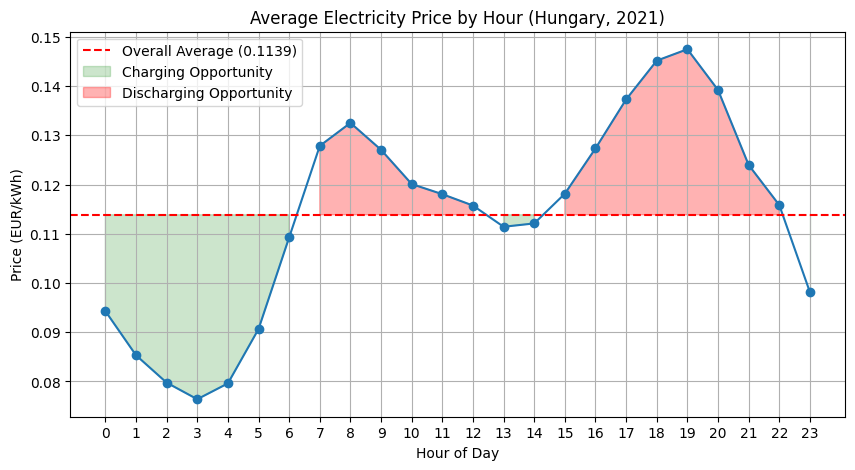

In [738]:
# Average price by hour (24h profile)
hourly_avg_df = (
    price_2021_df
    .groupby('hour')['Price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(hourly_avg_df['hour'], hourly_avg_df['Price'], marker='o')

# Add constant average line
avg_price = hourly_avg_df['Price'].mean()
plt.axhline(avg_price, linestyle='--', color='red', label=f'Overall Average ({avg_price:.4f})')

plt.fill_between(hourly_avg_df['hour'],
                 hourly_avg_df['Price'],
                 avg_price,
                 where=(hourly_avg_df['Price'] < avg_price),
                 alpha=0.2,
                 color='green',
                 label='Charging Opportunity')

plt.fill_between(hourly_avg_df['hour'],
                 hourly_avg_df['Price'],
                 avg_price,
                 where=(hourly_avg_df['Price'] > avg_price),
                 alpha=0.3,
                 color='red',
                 label='Discharging Opportunity')


plt.title('Average Electricity Price by Hour (Hungary, 2021)')
plt.xlabel('Hour of Day')
plt.ylabel('Price (EUR/kWh)')
plt.xticks(range(24))
plt.grid(True)
plt.legend()

plt.show()

Significant difference between hours 4 to 9 PM, and 0 to 5 AM

Drill down to specific dates:

In [739]:
def plot_price_window_with_daily_average(price_df, start_date, end_date, figsize=(16, 6)):
    """
    Plot hourly electricity prices between start_date and end_date,
    with a daily average line shown separately for each day.

    Parameters
    ----------
    price_df : pd.DataFrame
        Must contain:
        - 'Datetime' as datetime64
        - 'Price' as numeric
    start_date : str or datetime-like
        Example: '2021-01-01'
    end_date : str or datetime-like
        Example: '2021-01-07'
    figsize : tuple
        Matplotlib figure size
    """
    df = price_df.copy()
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    end_datetime = end_date + pd.Timedelta(days=1) - pd.Timedelta(hours=1)

    df = df[
        (df['Datetime'] >= start_date) &
        (df['Datetime'] <= end_datetime)
    ].copy()

    if df.empty:
        print('No data available in the selected date range.')
        return

    df = df.sort_values('Datetime').copy()
    df['date'] = df['Datetime'].dt.date
    df['daily_avg_price'] = df.groupby('date')['Price'].transform('mean')

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df['Datetime'], df['Price'], marker='o', linewidth=1.5, label='Hourly Price')

    for _, day_df in df.groupby('date'):
        ax.plot(
            day_df['Datetime'],
            day_df['daily_avg_price'],
            linestyle='--',
            linewidth=2,
            color='red'
        )

    ax.fill_between(
        df['Datetime'],
        df['Price'],
        df['daily_avg_price'],
        where=(df['Price'] < df['daily_avg_price']),
        alpha=0.2,
        color='green',
        label='Charging Opportunity'
    )

    ax.fill_between(
        df['Datetime'],
        df['Price'],
        df['daily_avg_price'],
        where=(df['Price'] > df['daily_avg_price']),
        alpha=0.3,
        color='red',
        label='Discharging Opportunity'
    )

    ax.plot([], [], linestyle='--', linewidth=2, color='red', label='Daily Average')

    ax.set_title(f'Electricity Price Profile from {start_date.date()} to {end_date.date()}')
    ax.set_xlabel('Datetime')
    ax.set_ylabel('Price (EUR/kWh)')
    ax.grid(True)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))

    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

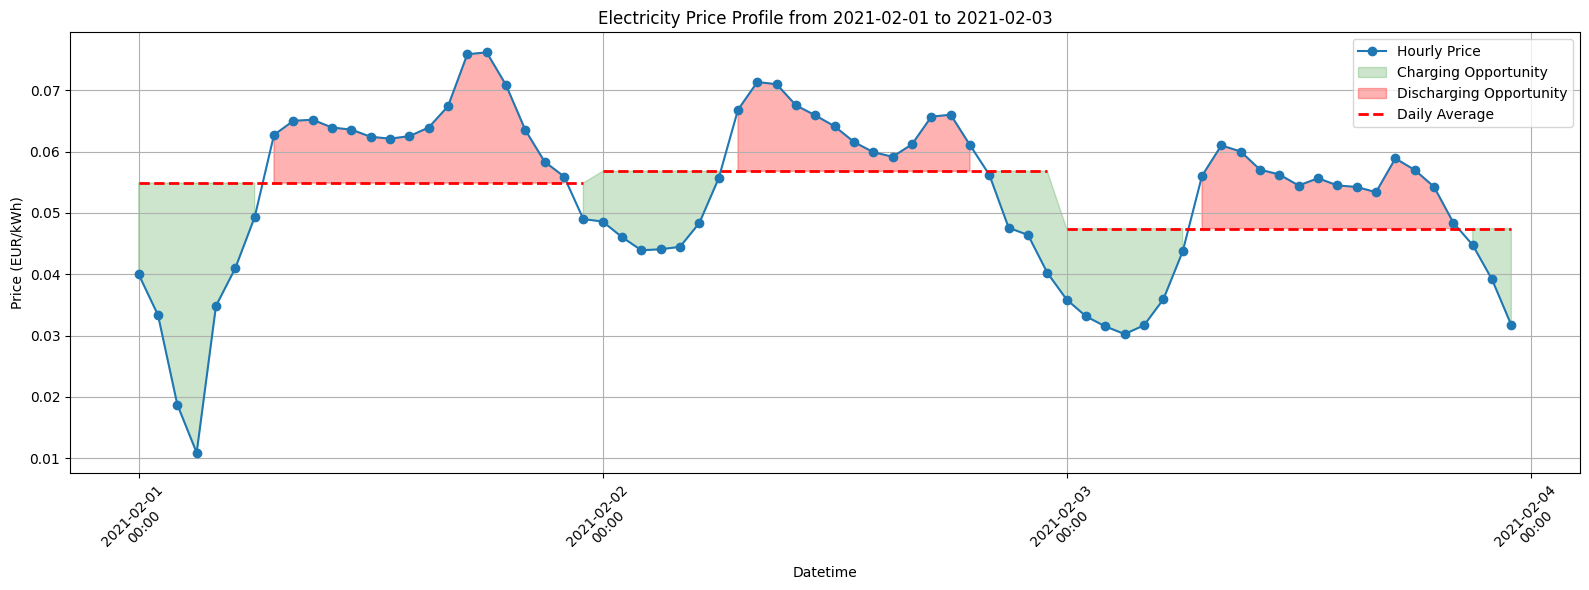

In [740]:
plot_price_window_with_daily_average(price_df, '2021-02-01', '2021-02-03')

Now let's see the same graphs on different months:

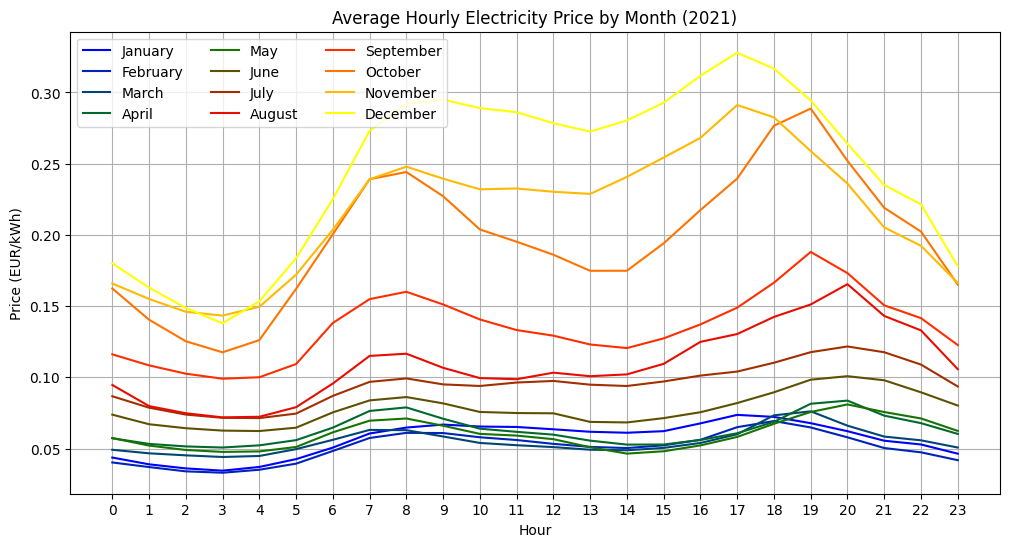

In [741]:
# Monthly hourly averages
monthly_hourly_df = (
    price_2021_df
    .groupby(['month','hour'])['Price']
    .mean()
    .reset_index()
)

# Pivot for easier plotting
monthly_pivot = monthly_hourly_df.pivot(
    index='hour',
    columns='month',
    values='Price'
)

monthly_pivot = monthly_pivot.sort_index(axis=1)

season_cmap = LinearSegmentedColormap.from_list(
    'season_cmap',
    ['blue', 'green', 'red', 'yellow'],
    N=12
)

colors = season_cmap(np.linspace(0, 1, 12))

plt.figure(figsize=(12, 6))

for i, month in enumerate(monthly_pivot.columns):
    plt.plot(
        monthly_pivot.index,
        monthly_pivot[month],
        label=calendar.month_name[month],
        color=colors[i]
    )

plt.title('Average Hourly Electricity Price by Month (2021)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/kWh)')
plt.xticks(range(24))
plt.legend(ncol=3)
plt.grid(True)

plt.show()

During October, November, and December the difference between early evening prices with midnight are the highest!

Consequence: We have daily data and it is better to not aggregate it.

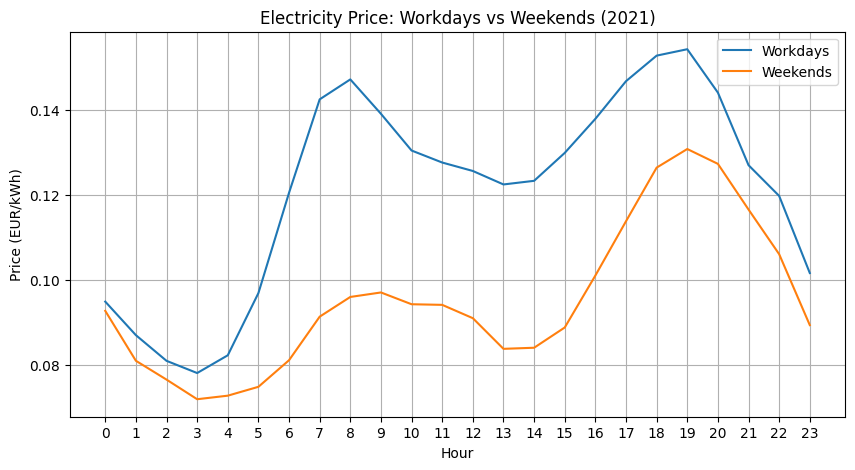

In [742]:
# Workdays vs Weekends
price_2021_df['is_weekend'] = price_2021_df['weekday'] >= 5

# Calculate hourly averages
weekday_weekend_df = (
    price_2021_df
    .groupby(['is_weekend','hour'])['Price']
    .mean()
    .reset_index()
)

# Split for plotting
weekday_df = weekday_weekend_df[weekday_weekend_df['is_weekend'] == False]
weekend_df = weekday_weekend_df[weekday_weekend_df['is_weekend'] == True]

plt.figure(figsize=(10,5))

plt.plot(weekday_df['hour'], weekday_df['Price'], label='Workdays')
plt.plot(weekend_df['hour'], weekend_df['Price'], label='Weekends')

plt.title('Electricity Price: Workdays vs Weekends (2021)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/kWh)')
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

No matter workday or weekend, the same pattern between early evening and midnight is visible.

Consequence: We don't need to partition our data based on weekday.

# Modeling

We start by partitioning data for year 2021, which we have essential data available.

Later we will extend our model to 2030, by timeseries prediction.

## Assumptions

- Consumer price is equal to generation, transmission and distribution value of Electricity. This is very big statement, but let's assume it.
- The top 10 units sold could be used to calculate the average battery capacity.
- BEV and PHEV are all EV.
- No technical barriers for EV about the duration and pace of discharge and charge phases. However we assume linear discharge and charge.
- Recharge after midnight fully restores the battery before morning departure.
- Conversion from common charging station into V2G station is the only cost of this project.
- Consider 'mid2021' in the station_conversion_cost_df in this model.


## Parameters:

- ev_param_v2g_compatible{v2g_station, ev_compatible, preferance}: The percentage of EV owners available V2G charging station at home, EV compatible with V2G, and prefer to participate in V2G
- ev_param_v2g_available{workday, weekend}: The percentage of EV owners pluged-in to station in workday and weekend during early evening hours
- ev_param_plugin_time: Based on EV owner behaviour, the time in early evening the EV could be pluged-in to station.
- ev_param_plugin_battery_percentage: The percentage of battery at the moment of pluging-in.
- ev_param_plugout_time: Based on EV owner behaviour, the time in the morning the EV could be pluged-out from station.
- ev_param_safe_capacity: The minimum capacity of battery to not discharge into grid.
- amortization_years: Amortization of investment. Default must assume 0.


## Objective

- The difference between discharge in early evening and charge during midnight must be calculated. It is interpreted as income for the grid.
- The profit must be calculated by income - cost

In [743]:
ev_param_v2g_compatible = {
    'v2g_station': 0.9, 
    'ev_compatible': 0.9, 
    'preferance': 0.9 
}

ev_param_v2g_available = {
    'workday': 0.9, 
    'weekend': 0.5
}

ev_param_plugin_time = 18      # early evening
ev_param_plugout_time = 7      # morning
ev_param_plugin_battery_percentage = 0.6667
ev_param_safe_capacity = 0.3334
amortization_years = 10

## Calculations

### Prepare EV stock and battery inputs for 2021

In [744]:
# EV stock in 2021
ev_2021 = ev_count_df.loc[ev_count_df['Year'] == 2021, 'EV'].iloc[0]

# Average battery capacity from top 10 best-selling EVs
weighted_avg_battery_capacity_kwh = (ev_profiles_df['Unit Sold 2025'] * ev_profiles_df['Battery_Capacity']).sum() / ev_profiles_df['Unit Sold 2025'].sum()

print('EV stock in 2021:', ev_2021)
print('Weighted average battery capacity (kWh):', round(weighted_avg_battery_capacity_kwh, 2))

EV stock in 2021: 28301
Weighted average battery capacity (kWh): 70.75


### Prepare station conversion cost

In [745]:
# Separate capex and annual opex
annual_metering_cost = station_conversion_cost_df.loc[
    station_conversion_cost_df['cost'] == 'Metering equipment',
    'mid2021'
].iloc[0]

capex_per_station = station_conversion_cost_df.loc[
    station_conversion_cost_df['cost'] != 'Metering equipment',
    'mid2021'
].sum()

annualized_capex_per_station = capex_per_station / amortization_years
annual_cost_per_station = annualized_capex_per_station + annual_metering_cost

print('CAPEX per station (EUR):', capex_per_station)
print('Annual metering cost per station (EUR/year):', annual_metering_cost)
print('Annualized CAPEX per station (EUR/year):', round(annualized_capex_per_station, 2))
print('Annual total cost per station (EUR/year):', round(annual_cost_per_station, 2))

CAPEX per station (EUR): 4350
Annual metering cost per station (EUR/year): 30
Annualized CAPEX per station (EUR/year): 435.0
Annual total cost per station (EUR/year): 465.0


### Model-compatible EV pool

In [746]:
v2g_compatibility_rate = (
    ev_param_v2g_compatible['v2g_station']
    * ev_param_v2g_compatible['ev_compatible']
    * ev_param_v2g_compatible['preferance']
)

eligible_ev_2021 = ev_2021 * v2g_compatibility_rate

print('Compatibility rate:', round(v2g_compatibility_rate, 4))
print('Eligible EVs in 2021:', round(eligible_ev_2021))

Compatibility rate: 0.729
Eligible EVs in 2021: 20631


### Build daily price features for 2021

In [747]:
price_2021_df = price_df[price_df['Datetime'].dt.year == 2021].copy()

price_2021_df['date'] = price_2021_df['Datetime'].dt.date
price_2021_df['hour'] = price_2021_df['Datetime'].dt.hour
price_2021_df['weekday'] = price_2021_df['Datetime'].dt.weekday
price_2021_df['day_type'] = np.where(price_2021_df['weekday'] < 5, 'workday', 'weekend')

### Extract daily charge and discharge prices

In [748]:
daily_rows = []

for current_date, day_df in price_2021_df.groupby('date'):
    day_df = day_df.sort_values('hour').copy()

    # Daily average price over all 24 hours
    daily_avg_price = day_df['Price'].mean()

    # Discharge window: 18:00 to 00:00
    # We consider hours 18, 19, 20, 21, 22, 23
    # Keep only hours with price above that day's average
    evening_df = day_df[
        (day_df['hour'] >= ev_param_plugin_time) &
        (day_df['hour'] < 24)
    ].copy()

    discharge_hours_df = evening_df[
        evening_df['Price'] > daily_avg_price
    ].copy()

    if discharge_hours_df.empty:
        avg_discharge_price = np.nan
        discharge_hours_count = 0
    else:
        avg_discharge_price = discharge_hours_df['Price'].mean()
        discharge_hours_count = len(discharge_hours_df)

    # Charge window: 22:00 to 07:00 next morning
    # We approximate this as:
    # same date hours 22, 23
    # plus next date hours 0..6
    # -----------------------------
    next_date = current_date + pd.Timedelta(days=1)

    # Next day daily average price over all 24 hours
    next_day_avg_price = price_2021_df[
        price_2021_df['date'] == next_date
    ]['Price'].mean()

    same_night_df = price_2021_df[
        (price_2021_df['date'] == current_date) &
        (price_2021_df['hour'] >= 22)
    ][['Datetime', 'date', 'hour', 'Price']].copy()

    next_morning_df = price_2021_df[
        (price_2021_df['date'] == next_date) &
        (price_2021_df['hour'] < ev_param_plugout_time)
    ][['Datetime', 'date', 'hour', 'Price']].copy()

    charge_window_df = pd.concat([same_night_df, next_morning_df], ignore_index=True)

    # Only charge when price is not above the NEXT day's average
    charge_hours_df = charge_window_df[
        charge_window_df['Price'] <= next_day_avg_price
    ].copy()

    if charge_hours_df.empty:
        avg_charge_price = np.nan
        charge_hours_count = 0
    else:
        avg_charge_price = charge_hours_df['Price'].mean()
        charge_hours_count = len(charge_hours_df)

    daily_rows.append({
        'date': current_date,
        'day_type': 'workday' if pd.Timestamp(current_date).weekday() < 5 else 'weekend',
        'daily_avg_price': daily_avg_price,
        'avg_discharge_price': avg_discharge_price,
        'discharge_hours_count': discharge_hours_count,
        'avg_charge_price': avg_charge_price,
        'charge_hours_count': charge_hours_count
    })

daily_price_df = pd.DataFrame(daily_rows)

# Dynamic spread
daily_price_df['spread'] = (
    daily_price_df['avg_discharge_price'] - daily_price_df['avg_charge_price']
)

daily_price_df.head(10)

,date,day_type,daily_avg_price,avg_discharge_price,discharge_hours_count,avg_charge_price,charge_hours_count,spread
0,2021-01-01,workday,0.039884,0.052387,6,0.041171,9,0.011216
1,2021-01-02,weekend,0.051420,0.058878,5,0.024615,6,0.034263
2,2021-01-03,weekend,0.038683,0.048002,5,0.029621,9,0.018381
3,2021-01-04,workday,0.051449,0.062310,4,0.035941,9,0.026369
4,2021-01-05,workday,0.052316,0.060337,3,0.038157,9,0.022180
5,2021-01-06,workday,0.052068,0.059257,4,0.038708,9,0.020550
6,2021-01-07,workday,0.065040,0.081333,3,0.049781,9,0.031552
7,2021-01-08,workday,0.074560,0.088285,2,0.034289,8,0.053996
8,2021-01-09,weekend,0.054987,0.066988,5,0.035680,7,0.031308
9,2021-01-10,weekend,0.047052,0.055298,5,0.034322,9,0.020976


Charge, discharge, and daily average for the Feb 2021

In [749]:
# Feb 2021 data
sample_df = daily_price_df[
    (daily_price_df['date'] >= pd.to_datetime('2021-02-01').date()) &
    (daily_price_df['date'] <= pd.to_datetime('2021-02-28').date())
].copy()


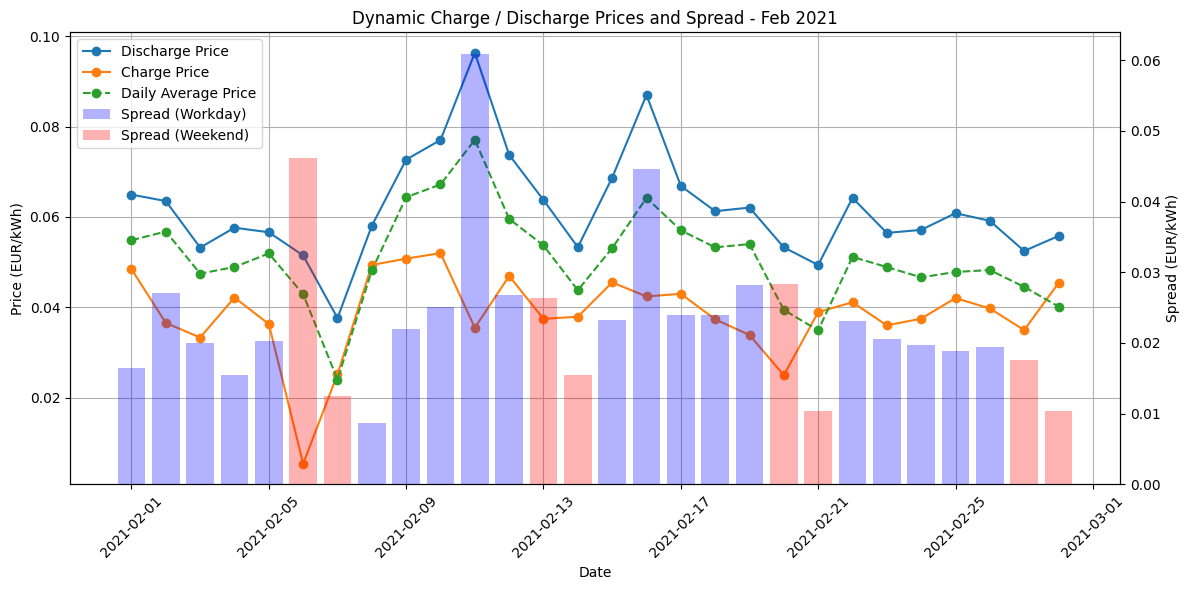

In [750]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Lines for prices
ax1.plot(sample_df['date'], sample_df['avg_discharge_price'], marker='o', label='Discharge Price')
ax1.plot(sample_df['date'], sample_df['avg_charge_price'], marker='o', label='Charge Price')
ax1.plot(sample_df['date'], sample_df['daily_avg_price'], marker='o', linestyle='--', label='Daily Average Price')

ax1.set_xlabel('Date')
ax1.set_ylabel('Price (EUR/kWh)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

# Bar colors: weekend = red, workday = blue
bar_colors = sample_df['day_type'].map({
    'workday': 'blue',
    'weekend': 'red'
})

# Bars for spread
ax2 = ax1.twinx()
ax2.bar(sample_df['date'], sample_df['spread'], alpha=0.3, color=bar_colors, label='Spread')
ax2.set_ylabel('Spread (EUR/kWh)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()

from matplotlib.patches import Patch
bar_legend = [
    Patch(facecolor='blue', alpha=0.3, label='Spread (Workday)'),
    Patch(facecolor='red', alpha=0.3, label='Spread (Weekend)')
]

ax1.legend(lines1 + bar_legend, labels1 + ['Spread (Workday)', 'Spread (Weekend)'], loc='upper left')

plt.title('Dynamic Charge / Discharge Prices and Spread - Feb 2021')
plt.tight_layout()
plt.show()

Investigate around Feb 20 to 22 to find out the anomality in the charge price and daily average:

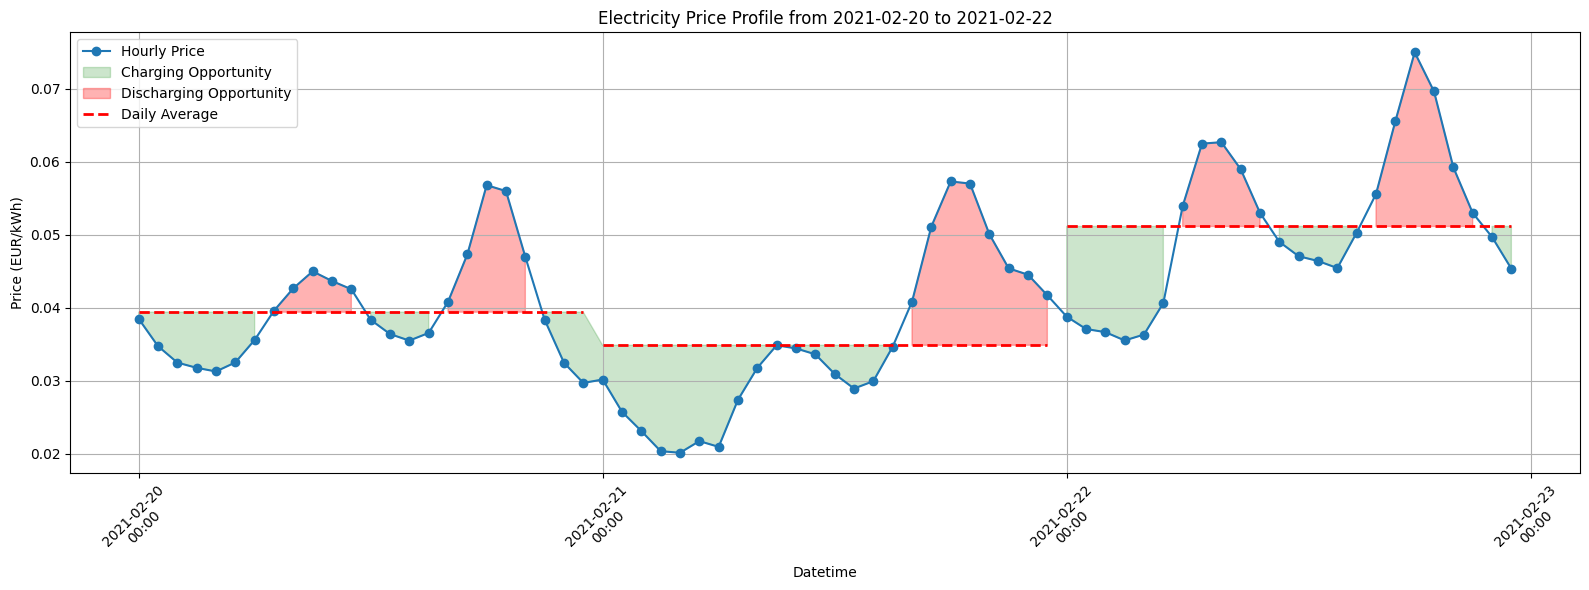

In [751]:
plot_price_window_with_daily_average(price_df, '2021-02-20', '2021-02-22')

The spread is too little! The average price of evening hours in Feb 21 is almost equal to average price of midnight hours in the next day.

Let's fact check:

In [752]:
# Define the two periods
evening_start = pd.to_datetime('2021-02-21 16:00')
evening_end   = pd.to_datetime('2021-02-21 23:00')

night_start   = pd.to_datetime('2021-02-22 00:00')
night_end     = pd.to_datetime('2021-02-22 08:00')

# Evening prices (potential discharge)
evening_avg = price_df[
    (price_df['Datetime'] >= evening_start) &
    (price_df['Datetime'] <= evening_end)
]['Price'].mean()

# Night prices (charging)
night_avg = price_df[
    (price_df['Datetime'] >= night_start) &
    (price_df['Datetime'] <= night_end)
]['Price'].mean()

print(f"Average price Feb 21 18:00–23:00 : {evening_avg:.4f} EUR/kWh")
print(f"Average price Feb 22 00:00–05:00 : {night_avg:.4f} EUR/kWh")
print(f"Spread (evening - night)        : {(evening_avg-night_avg):.4f} EUR/kWh")

Average price Feb 21 18:00–23:00 : 0.0485 EUR/kWh
Average price Feb 22 00:00–05:00 : 0.0449 EUR/kWh
Spread (evening - night)        : 0.0036 EUR/kWh


### Daily available EV count

In [753]:
daily_price_df['availability_rate'] = daily_price_df['day_type'].map(ev_param_v2g_available)

daily_price_df['available_ev_count'] = eligible_ev_2021 * daily_price_df['availability_rate']

daily_price_df.head()

,date,day_type,daily_avg_price,avg_discharge_price,discharge_hours_count,avg_charge_price,charge_hours_count,spread,availability_rate,available_ev_count
0,2021-01-01,workday,0.039884,0.052387,6,0.041171,9,0.011216,0.9,18568.2861
1,2021-01-02,weekend,0.051420,0.058878,5,0.024615,6,0.034263,0.5,10315.7145
2,2021-01-03,weekend,0.038683,0.048002,5,0.029621,9,0.018381,0.5,10315.7145
3,2021-01-04,workday,0.051449,0.062310,4,0.035941,9,0.026369,0.9,18568.2861
4,2021-01-05,workday,0.052316,0.060337,3,0.038157,9,0.022180,0.9,18568.2861


### Energy available per EV

In [754]:
usable_energy_per_ev_kwh = avg_battery_capacity_kwh * (1 - ev_param_safe_capacity)

print('Usable energy per EV (kWh):', round(usable_energy_per_ev_kwh, 2))

Usable energy per EV (kWh): 47.16


In [755]:
daily_price_df['energy_to_grid_kwh'] = (
    daily_price_df['available_ev_count'] * usable_energy_per_ev_kwh
)

### Daily income from arbitrage

In [756]:
# If spread is negative, this gives a loss. 
# Allow operation only when profitable:
daily_price_df['profitable_spread'] = daily_price_df['spread'].clip(lower=0)
daily_price_df['income_eur_profitable_only'] = (
    daily_price_df['energy_to_grid_kwh'] * daily_price_df['profitable_spread']
)
daily_price_df.head()

,date,day_type,daily_avg_price,avg_discharge_price,discharge_hours_count,avg_charge_price,charge_hours_count,spread,availability_rate,available_ev_count,energy_to_grid_kwh,profitable_spread,income_eur_profitable_only
0,2021-01-01,workday,0.039884,0.052387,6,0.041171,9,0.011216,0.9,18568.2861,875768.939032,0.011216,9822.235190
1,2021-01-02,weekend,0.051420,0.058878,5,0.024615,6,0.034263,0.5,10315.7145,486538.299462,0.034263,16670.261754
2,2021-01-03,weekend,0.038683,0.048002,5,0.029621,9,0.018381,0.5,10315.7145,486538.299462,0.018381,8943.006423
3,2021-01-04,workday,0.051449,0.062310,4,0.035941,9,0.026369,0.9,18568.2861,875768.939032,0.026369,23093.053846
4,2021-01-05,workday,0.052316,0.060337,3,0.038157,9,0.022180,0.9,18568.2861,875768.939032,0.022180,19424.555068


### Annual station cost

In [757]:
station_count = eligible_ev_2021
annual_cost_total = station_count * annual_cost_per_station

print('Estimated station count:', round(station_count))
print('Annual total cost (EUR/year):', round(annual_cost_total, 2))

Estimated station count: 20631
Annual total cost (EUR/year): 9593614.49


### Annual profit

In [758]:
annual_income_eur = daily_price_df['income_eur_profitable_only'].sum()

annual_profit_eur = annual_income_eur - annual_cost_total

model_summary = pd.DataFrame({
    'Metric': [
        'EV stock 2021',
        'Eligible EVs',
        'Average battery capacity (kWh)',
        'Usable energy per EV (kWh)',
        'Station annual cost per unit (EUR/year)',
        'Total annual income (EUR)',
        'Total annual cost (EUR)',
        'Annual profit (EUR)',
    ],
    'Value': [
        ev_2021,
        eligible_ev_2021,
        avg_battery_capacity_kwh,
        usable_energy_per_ev_kwh,
        annual_cost_per_station,
        annual_income_eur,
        annual_cost_total,
        annual_profit_eur,
    ]
})

model_summary['Value'] = model_summary['Value'].apply(
    lambda x: f"{x:,.0f}" if abs(x) >= 1 else f"{x:,.4f}"
)

model_summary

,Metric,Value
0,EV stock 2021,"28,301"
1,Eligible EVs,"20,631"
2,Average battery capacity (kWh),71
3,Usable energy per EV (kWh),47
4,Station annual cost per unit (EUR/year),465
5,Total annual income (EUR),"14,861,444"
6,Total annual cost (EUR),"9,593,614"
7,Annual profit (EUR),"5,267,830"


# Extend Data using Time Series Prediction

# Data Alignments

### Notes:

- The Russia-Ukraine war started in Feb 2022. Maybe it had impact on price of energy... check that.

# Readings

- How Vehicle-to-Grid and Smart Charging Influence EV Battery Aging https://cdn-website.mobilityhouse.com/25-10_WP_RWTH_EN_b135edc9631bdfda6acb27a816953fa9.pdf
- Vehicle to Business: four uses cases https://scale-horizon.eu/use-cases/vehicle-to-business/
- Analysis of the Feasibility of Integrating Electric Vehicles into Vehicle-to-Grid Systems in Hungary https://www.scientific.net/AST.165.235
- Vehicle-to-grid feasibility: A techno-economic analysis of EV-based energy storage https://doi.org/10.1016/j.apenergy.2017.01.102
- Bidirectional battery electric vehicle fleets in commercial applications: Exploring synergies and substitutions with stationary battery storage https://doi.org/10.1016/j.apenergy.2025.126884
- Modeling and evaluating bidirectionally chargeable electric vehicles in the future European energy system https://doi.org/10.1016/j.egyr.2022.10.277